In [2]:
#%load_ext autoreload
#%autoreload 2

In [39]:
import torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
from safetensors.torch import load_file
from preprocessor import Preprocessor, get_density_at_surface_tensor

$$
\renewcommand{\E}{\mathbb E}
\renewcommand{\E}{\mathbb R}
\renewcommand{\V}{\mathbb V}
\renewcommand{\C}{\mathcal C}
$$

# Constraint on Density with Projection operator


In this notebook we show the generation of (T, S) profile with a generative model with a constraint applied on density $g(T, S)$ profiles. 


- $K$ : number of vertical layers
- $x \in \R^{K \times 2}$ : (T, S) profiles
- $g : \R^2 \to \R$ : observation function (density in this case)
- $h : \R^K \to \R^K$ : constraint function on the profiles


In the following code we do the three tasks : 
1. From $N$ (T, S) profiles we train a diffusion model to sample from the observed distribution. 
2. We show that generated profiles doens't naturally respect the constraint 
3. We change the sampling step during generation to respect given constraint

# 0. Data loading

<bound method FigureBase.suptitle of <Figure size 2000x500 with 3 Axes>>

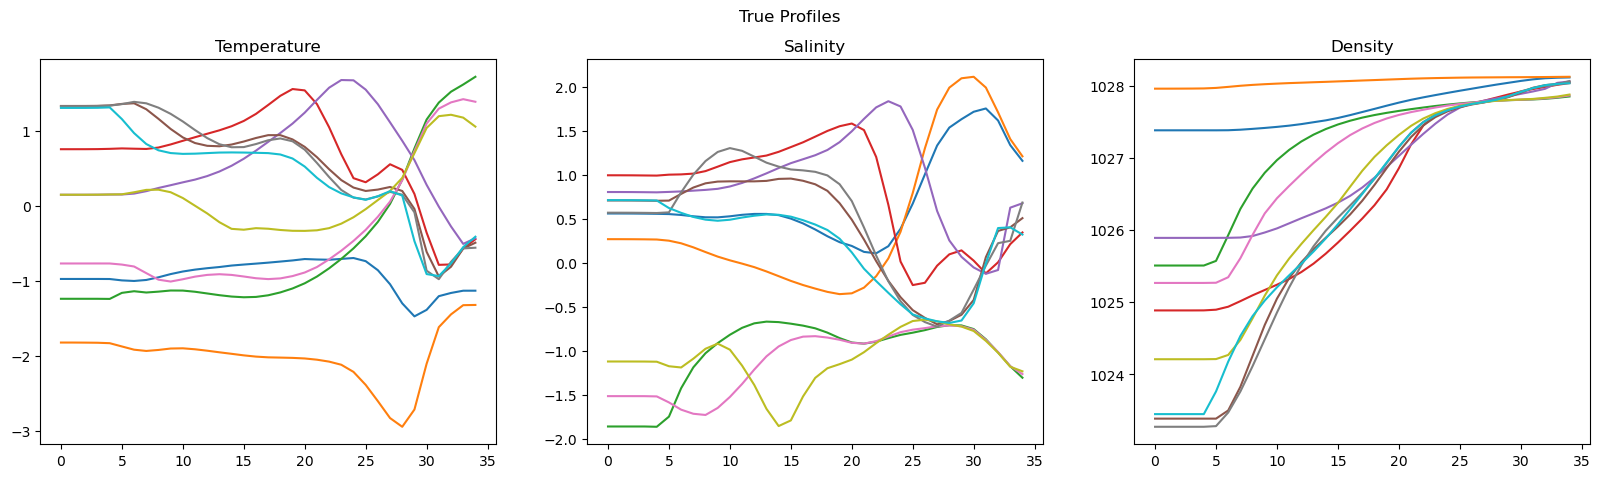

In [6]:
p, levels = 10, 35
stats = load_file('profile_states.safetensor')
toce = torch.tensor(np.load('00000.toce.npy')[:levels, p:-p, p:-p][None])
soce = torch.tensor(np.load('00000.soce.npy')[:levels, p:-p, p:-p][None])

density = get_density_at_surface_tensor(toce, soce)

norm = Preprocessor(toce.shape, stats['mean'], stats['std'], levels)

data_flat_normalised = norm.forward(norm.flatten(toce), norm.flatten(soce))

fig, axs = plt.subplots(1,3,figsize=(20,5))
fig.suptitle('True Profiles')
rindex = torch.randint(0, data_flat_normalised.shape[0], (10,))
axs[0].set_title('Temperature')
axs[0].plot(data_flat_normalised[rindex, :levels].T)
axs[1].set_title('Salinity')
axs[1].plot(data_flat_normalised[rindex, levels:].T)
axs[2].set_title('Density')
axs[2].plot(norm.flatten(density)[rindex, :].T)
fig.suptitle

## 1. Model training

In [21]:
from network import Net
import torch.optim as optim
from tqdm import trange
import torch.distributions as D

In [55]:
targets = data_flat_normalised
N, d = targets.shape

prior = D.MultivariateNormal(torch.zeros(d), torch.eye(d, d))
priors = prior.sample((N,))

In [56]:
u_theta = Net(d)
opt = optim.Adam(u_theta.parameters(), lr=0.001)
epochs = 3000
losses = torch.zeros(epochs)

for epoch in trange(epochs) :
    ts = torch.rand((N, 1))
    xs = ts*targets + (1-ts)*priors # sample x from p(x | t, z)
    us = targets - priors
    opt.zero_grad()
    loss = torch.nn.functional.mse_loss(u_theta(xs, ts), us)
    loss.backward()
    opt.step()
    losses[epoch] = loss.item()

100%|██████████| 3000/3000 [02:56<00:00, 17.04it/s]


## 2. Generate samples

In [47]:
def plot_profiles(x, norm, title='') :  
    toce_gen, soce_gen = norm.backward(x)
    density_gen = get_density_at_surface_tensor(toce_gen, soce_gen)

    fig, axs = plt.subplots(1,3,figsize=(20,5))
    fig.suptitle(title)
    rindex = torch.randint(0, x.shape[0], (10,))
    axs[0].set_title('Temperature')
    axs[0].plot(x[rindex, :levels].T)
    axs[1].set_title('Salinity')
    axs[1].plot(x[rindex, levels:].T)
    axs[2].set_title('Density')
    axs[2].plot(density_gen[rindex, :].T)
    plt.show()

In [63]:
S = 10
x_init = prior.sample((S,))

with torch.no_grad() :
    x, t= x_init.clone(), torch.zeros((S,1))
    dt = 0.001
    for i in range(int(1 // dt) +1 ) : 
        x = x + dt*u_theta(x,t)
        t = t + dt

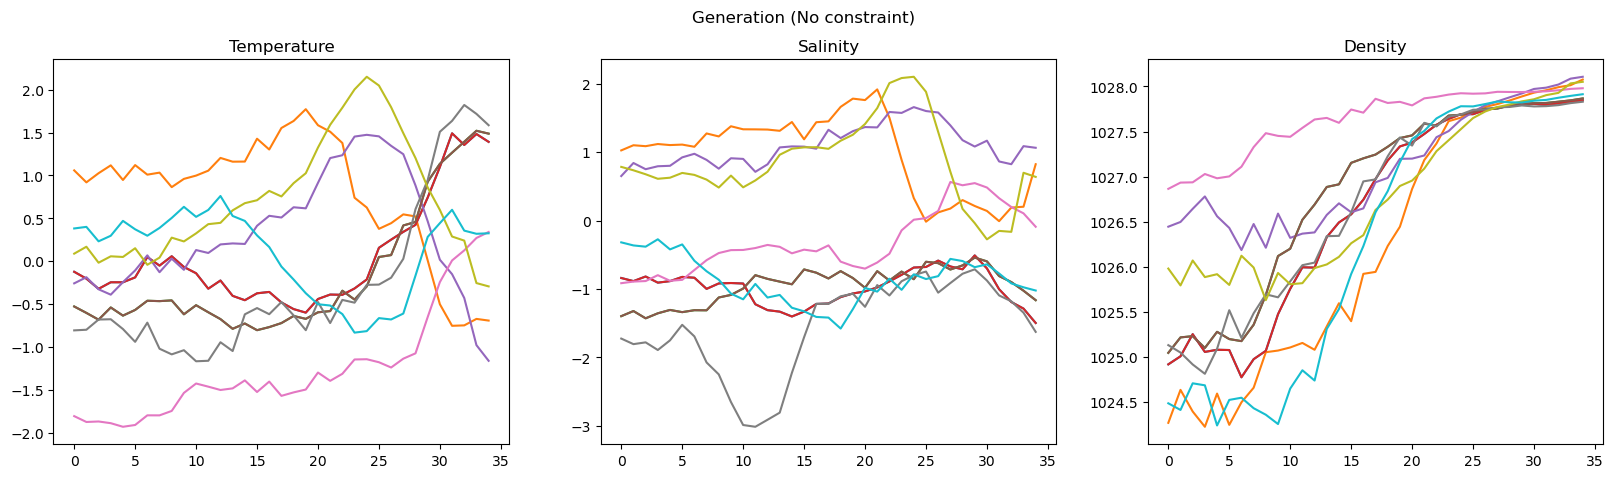

In [64]:
plot_profiles(x, norm, 'Generation (No constraint)')

## 3. Constrained generation 

Our objective is sample from the learned distribution constrained by $h$ on the observation $g(x)$

$$
\min_{q} KL(q || p) \quad \text{ s.t } {\E_{q}[h(g(x))]} =0 \text{ and }\E_{q}[||h(g(x))||^2] \leq \epsilon
$$

In a variational setup [1] we can operate this sampling formulating a Lagrangian and operating a gradient ascent-descent method. 

**Constraint generation with projection operator :**

Although in our case we don't know how to compute $\nabla_x h$, but we have access to a proximal operator. 

$$
\mathcal P(g) \triangleq_{ \arg \min_{z \in \mathcal C}} ||g - z||^2
$$

where $\mathcal C = \{ z | h(z) = 0 \}$ is the set that respect the constraint. 

We leverage this projection operator and split our problem in two variables : $(x \in \R^{2 \times K}, z \R^{K})$ : 

$$
\min_{q(x, z)} KL(q(x) || p(x)) + \E[X_{\mathcal C}(z)] \quad \text{ s.t } {\E_{q(x, z)}[g(x)-  z]} =0 \text{ and } \E_{q(x,z)}[||g(x) - z||^2] \leq \epsilon_2
$$

Where $X_{\mathcal C}(x) = \{+ \infty \text{ if } x \notin \mathcal C; 0 \text{ if } x \in \mathcal C\}$ is an indicator function. This is similar to what is done in [2] although the objective is slighly different, we are not aiming to get samples respecting exactly the constraint but rather to do sampling respecting the constraint in expectation (with penalization on the variance) in a case where we have a non-differentiable constraint. 

$$
\begin{align*}
x_{t+1} &= x + \nabla_x \log p(x) - \nabla_x [\rho ||g(x) - z||^2 + \lambda^T (g(x)-z)] \text{ - Sampling} \\
z_{t+1} &= \arg \min_{z \in \mathcal C} \rho ||g(x) - z||^2 + \lambda^T (g(x)-z) =  \arg \min_{z \in \mathcal C} ||g(x) + (2\rho)^{-1} \lambda - z||^2\\
\lambda_{t+1} &= \lambda_t + \eta \E[g(x) - z]\\
\rho_{t+1} &=  \big [\rho + \eta \E_{q(x,z)}[||g(x) - z||^2] - \epsilon \big ]_{+}
\end{align*}
$$

This algorithm will generally works as long as we have a projection operator for our constraint.  


In [ ]:
def L_r(gx, z, lbd, rho) : 
    """
        gx (b k)
        z (b k)
        lbd (k)
        rho (1)
    """
    E_d_sq = ((gx - z)**2).sum(axis=-1).mean()
    E_d = (gx - z).mean(axis=0) # (k)
    return rho*E_d_sq + lbd@E_d

def sampling_with_constraint(x_init, L_r, g, h, dt=0.001, eta=1.0, eta_rho=1e-4, epsilon=1e-7) : 
        # Init variables 
        x = x_init.clone()
        x.requires_grad_(True) # (n k 2)

        t = torch.zeros((x.shape[0],1))
        lbd = torch.zeros(1, g(x).shape[1], requires_grad=True) # (k)
        rho = torch.full((1,1), 0.01, requires_grad=True)
        
        metrics = []

        for i in (pbar := trange(int(1 // dt))):
            z = h.projection(g(x) + lbd / (2*rho))
            l = L_r(g(x), z, lbd, rho)
            l.backward()

            with torch.no_grad():
                x += dt*(u_theta(x.detach(), t) - x.grad)
                lbd += eta*lbd.grad
                rho += eta_rho*rho.grad
                rho.clamp_(min=0.01)
                t = t + dt

            x.grad, lbd.grad = None, None
            metric = {'t' : t.mean().item(), 'mean(lbd)' : lbd.mean().item()}
            pbar.set_postfix(metric)
            metrics.append(metric)


        x = x.detach()
        metrics = pd.DataFrame(metrics)
        return x, metrics 

**Constraints :** 

*1. Average profile* 

Our first constraint is very simple : we want the generated fields have a density profile that is the close to the average density profile $\kappa \in \R^k$. 

This gives a naive projection operator $\mathcal P(g) \triangleq \kappa$

*2. Isotonic profile* 

A more sensible constraint is that the density profiles monotonically increase with depth $g(x)_{k+1} \leq g(x)_{k} \quad \forall k \in \{0 \times K\}$.

In this setup we define the projection as being the closest profile that monotonically increase $\mathcal P(g) \triangleq  \arg \min_{z \in \mathcal C} ||g -z||^2$ which is the constraint enforced by isotonic regression.

In [69]:
from scipy.optimize import isotonic_regression

def g(x) :
    """
        Density estimation kernel
        x (b, k, 2) -> g(x) (b, k)
    """
    toce_gen, soce_gen = norm.backward(x)
    density = get_density_at_surface_tensor(toce_gen, soce_gen)
    return density

class IsotonicConstraint() : 
    name = 'Isotonic'

    @staticmethod
    def isotonic(gx) :
        return torch.tensor(np.stack([isotonic_regression(dg.detach().clone()).x for dg in gx]), dtype=gx.dtype)
    
    @staticmethod
    @torch.no_grad()
    def projection(gx):
        return IsotonicConstraint.isotonic(gx)


class DensityProfile() : 
    name = 'Average density Profile'

    @staticmethod
    @torch.no_grad()
    def projection(gx):
        return stats['avg_density'][None].repeat((gx.shape[0], 1)).to(gx.device, gx.dtype)
    

class ClusterConstraint() : 
    name = "Clusters"
    cl_c = torch.tensor(km.cluster_centers_)
    weights = torch.ones(len(cl_c)) / len(cl_c)
    
    @staticmethod
    def closest_cluster(gx, cl_c) : 
        gx = gx.detach()
        count_clusters = (ClusterConstraint.weights * gx.shape[0]).to(int)
        count_clusters[0] += gx.shape[0] - count_clusters.sum()
        r_cl_c = torch.concat([torch.stack([ClusterConstraint.cl_c[i]]*n) for i, n in enumerate(count_clusters)]).to(gx.dtype)
        cost = ((r_cl_c[None] - gx[:, None])**2).sum(axis=-1)
        row_index, col_index = linear_sum_assignment(cost)
        return r_cl_c[col_index]
    
    @staticmethod
    @torch.no_grad()
    def projection(gx):
        return ClusterConstraint.closest_cluster(gx, ClusterConstraint.cl_c)
    


NameError: name 'km' is not defined

In [36]:
x_init = prior.sample((10,))

In [67]:
h = DensityProfile
x, metrics = sampling_with_constraint(x_init, L_r, g, h, dt=0.001, eta=0.5, eta_rho=1e-5, epsilon=1e-2) 

100%|██████████| 999/999 [00:02<00:00, 430.93it/s, t=0.999, mean(lbd)=-2.73]    


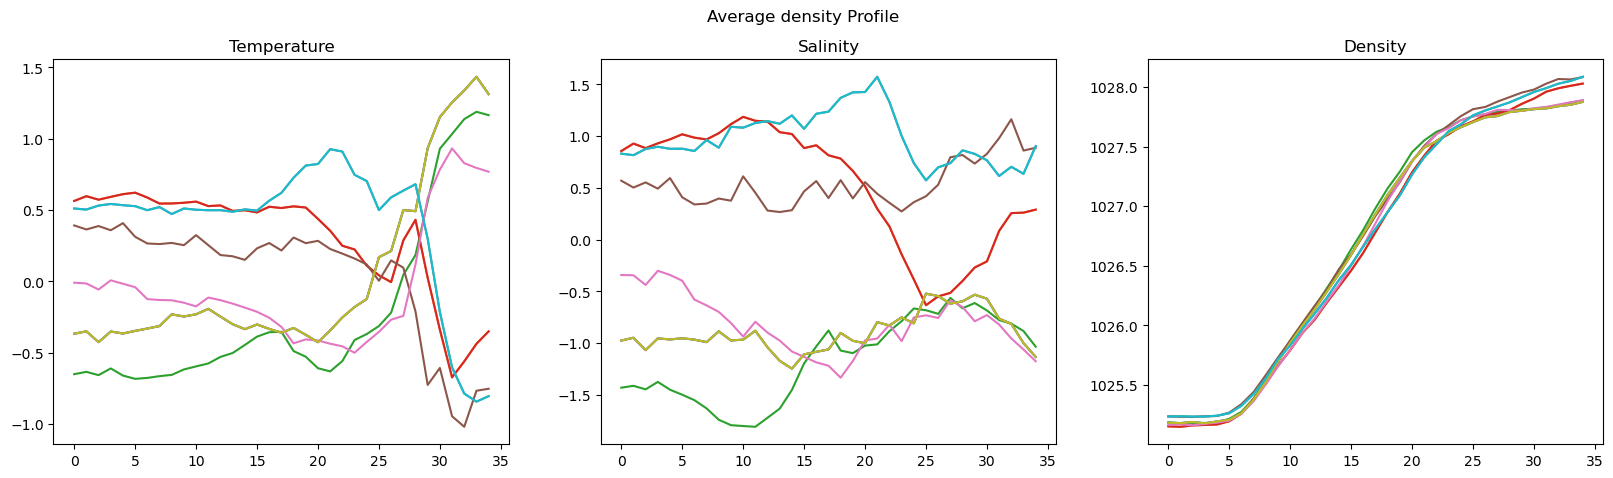

In [68]:
plot_profiles(x, norm, h.name)

In [65]:
h = IsotonicConstraint
x, metrics = sampling_with_constraint(x_init, L_r, g, h, dt=0.001, eta=0.5, eta_rho=1e-5, epsilon=1e-2) 

100%|██████████| 999/999 [00:02<00:00, 346.69it/s, t=0.999, mean(lbd)=-1.53e-5]


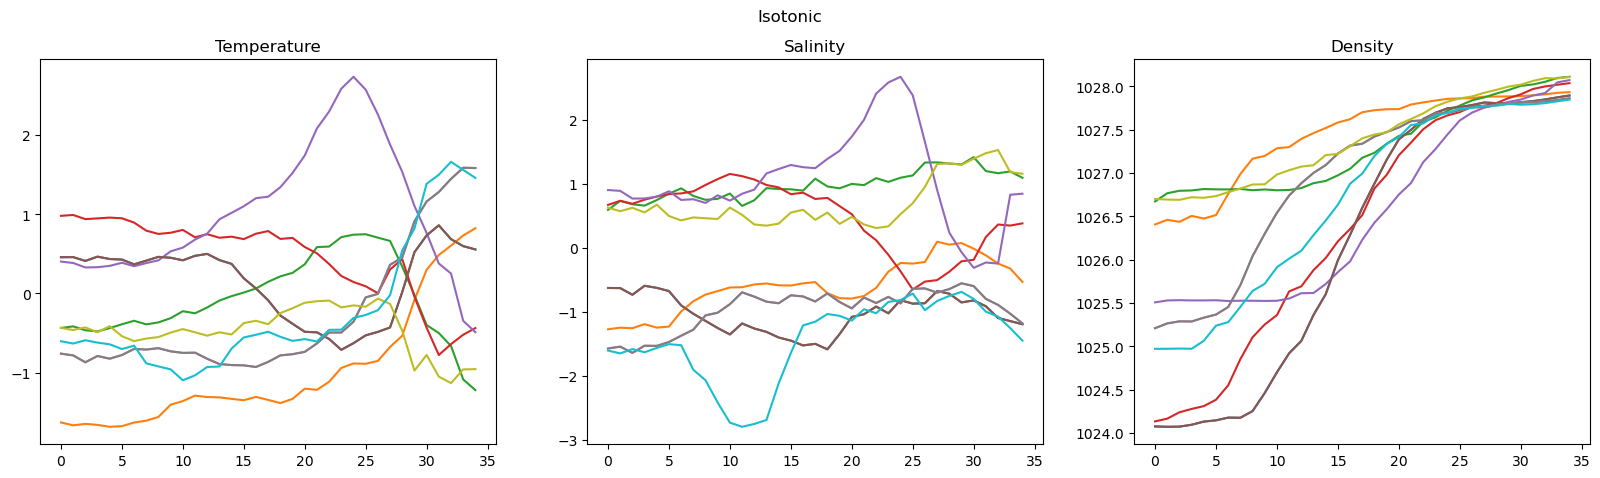

In [66]:
plot_profiles(x, norm, h.name)

## References 

[1] Chamon, L. F., Karimi, M. R., & Korba, A. (2024). Constrained sampling with primal-dual Langevin Monte Carlo. Advances in Neural Information Processing Systems, 37, 29285-29323.

[2] Blanke, M., Qu, Y., Shamekh, S., & Gentine, P. (2025). Strictly Constrained Generative Modeling via Split Augmented Langevin Sampling. arXiv preprint arXiv:2505.18017.